# Hotstart and chained runs

**What this shows:** how to save the wave field at the end of a SWAN run and start the
next run from it, for example to split a long hindcast or to skip spin-up.

**Prerequisites:** [Tutorial 6: A nonstationary hindcast](../tutorial/06_nonstationary_hindcast.ipynb).

**You will learn:**

- how to write hotfiles with `hotfile` and `hottimes`
- how to start a run from a hotfile with `INITIAL HOTSTART`
- what must stay the same between chained runs

**Data used:** `etopo15s_perth.nc`, `era5-20230101.nc` and
`ww3-spectra-20230101-short.nc`. The runs use Docker and are skipped without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from rompy.backends import DockerConfig
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceWavespectra
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_swan.boundary import Boundnest1
from rompy_swan.components.boundary import INITIAL
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.components.group import LOCKUP, OUTPUT, PHYSICS, STARTUP
from rompy_swan.components.lockup import COMPUTE_NONSTAT, HOTFILE
from rompy_swan.components.output import POINTS, TABLE
from rompy_swan.components.physics import FRICTION_JONSWAP, GEN3, TRIAD
from rompy_swan.components.startup import COORDINATES, MODE, SET
from rompy_swan.config import SwanConfig
from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid
from rompy_swan.interface import BoundaryInterface, DataInterface
from rompy_swan.subcomponents.boundary import HOTSINGLE
from rompy_swan.subcomponents.spectrum import SPECTRUM
from rompy_swan.subcomponents.startup import SPHERICAL

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "hotstart_and_chained_runs"
shutil.rmtree(OUT_DIR, ignore_errors=True)

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)


def swan_config(lockup: LOCKUP, initial: INITIAL | None = None) -> SwanConfig:
    """The hindcast model of Tutorial 6 with the given computation and initial state."""
    return SwanConfig(
        startup=STARTUP(
            set=SET(direction_convention="nautical"),
            mode=MODE(kind="nonstationary"),
            coordinates=COORDINATES(kind=SPHERICAL()),
        ),
        cgrid=REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)),
        inpgrid=DataInterface(
            bottom=SwanDataGrid(
                var="bottom",
                source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
                z1="z",
                fac=-1.0,
                coords={"x": "longitude", "y": "latitude"},
                buffer=0.1,
            ),
            input=[
                SwanDataGrid(
                    var="wind",
                    source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
                    z1="u10",
                    z2="v10",
                    coords={"x": "longitude", "y": "latitude"},
                    filter=Filter(sort={"coords": ["latitude"]}),
                    buffer=0.25,
                )
            ],
        ),
        boundary=BoundaryInterface(
            kind=Boundnest1(
                id="ww3",
                source=SourceWavespectra(
                    uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
                ),
                sel_method="idw",
                sel_method_kwargs={"tolerance": 1.5},
                spacing=0.1,
            )
        ),
        initial=initial,
        physics=PHYSICS(gen=GEN3(), friction=FRICTION_JONSWAP(cfjon=0.038), triad=TRIAD()),
        output=OUTPUT(
            points=POINTS(sname="sites", xp=[114.8, 115.71], yp=[-32.1, -31.98]),
            table=TABLE(sname="sites", format="noheader", fname="sites.txt", output=["time", "hsign"]),
        ),
        lockup=lockup,
    )

## 1. Writing hotfiles

`hotfile` names the file and `hottimes` says when to write it: indices of the
computation times (`-1` is the last) or datetimes. rompy-swan splits the computation
at those times and adds the time to the file name.

In [2]:
first = swan_config(
    LOCKUP(
        compute=COMPUTE_NONSTAT(initstat=True, hotfile=HOTFILE(fname="hotstart.txt"), hottimes=[-1])
    )
)
first_period = TimeRange(start="2023-01-01T06:00", end="2023-01-01T09:00", interval="10m")
first_run = ModelRun(run_id="first", period=first_period, output_dir=OUT_DIR, config=first)
first_ws = Path(first_run())
print("\n".join(line for line in (first_ws / "INPUT").read_text().splitlines() if line.startswith(("COMPUTE", "HOTFILE"))))

COMPUTE STATIONARY time=20230101.060000
COMPUTE NONSTATIONARY tbegc=20230101.060000 deltc=600.0 SEC tendc=20230101.090000
HOTFILE fname='hotstart_20230101T090000.txt'


## 2. Starting from a hotfile

The second run starts where the first ended. `INITIAL` with `HOTSINGLE` reads the
hotfile instead of starting from a stationary computation. The file must be copied
into the second workspace.

In [3]:
second = swan_config(
    LOCKUP(compute=COMPUTE_NONSTAT()),
    initial=INITIAL(kind=HOTSINGLE(fname="hotstart_20230101T090000.txt")),
)
second_period = TimeRange(start="2023-01-01T09:00", end="2023-01-01T12:00", interval="10m")
second_run = ModelRun(run_id="second", period=second_period, output_dir=OUT_DIR, config=second)
second_ws = Path(second_run())
print(second.initial.render())

INITIAL HOTSTART SINGLE fname='hotstart_20230101T090000.txt' FREE


For comparison, a single run over the whole six hours:

In [4]:
full = swan_config(LOCKUP(compute=COMPUTE_NONSTAT(initstat=True)))
full_period = TimeRange(start="2023-01-01T06:00", end="2023-01-01T12:00", interval="10m")
full_run = ModelRun(run_id="full", period=full_period, output_dir=OUT_DIR, config=full)
full_ws = Path(full_run())

## 3. Running the chain

In [5]:
def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
ran = False
if docker_available() and first_run.run(backend, workspace_dir=first_ws):
    shutil.copy(first_ws / "hotstart_20230101T090000.txt", second_ws)
    ran = second_run.run(backend, workspace_dir=second_ws) and full_run.run(
        backend, workspace_dir=full_ws
    )
print("Runs completed" if ran else "Docker is not available or a run failed")

Runs completed


In [6]:
def read_sites(workspace: Path) -> pd.DataFrame:
    """Read the table of wave heights at the two points."""
    table = pd.read_csv(workspace / "sites.txt", sep=r"\s+", names=["time", "hs"], dtype={"time": str})
    table["time"] = pd.to_datetime(table["time"], format="%Y%m%d.%H%M%S")
    table["site"] = ["offshore", "Cottesloe"] * (len(table) // 2)
    return table

## 4. Results

The chained runs follow the single run closely, within about a centimetre: the second
run continues from the wave field at 09:00 instead of starting again from a
stationary computation.

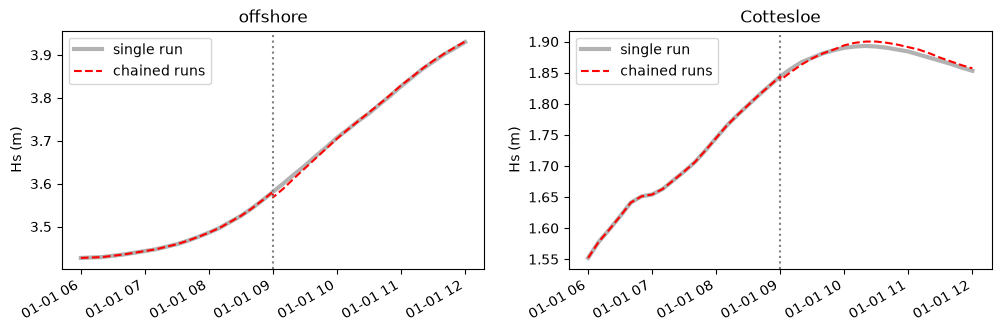

In [7]:
if ran:
    chained = pd.concat([read_sites(first_ws), read_sites(second_ws)])
    single = read_sites(full_ws)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True)
    for ax, site in zip(axes, ["offshore", "Cottesloe"]):
        one = single[single.site == site]
        two = chained[chained.site == site]
        ax.plot(one.time, one.hs, "k", linewidth=3, alpha=0.3, label="single run")
        ax.plot(two.time, two.hs, "r--", label="chained runs")
        ax.axvline(pd.Timestamp("2023-01-01T09:00"), color="0.5", linestyle=":")
        ax.set(title=site, ylabel="Hs (m)")
        ax.legend()
    fig.autofmt_xdate()

## 5. What must match

- The computational and spectral grids must be identical in both runs.
- A run with MPI writes one hotfile per process; read them with `HOTMULTIPLE`, or
  concatenate them first (SWAN's `hcat` tool).
- The second run must start at the time the hotfile was written.

## Summary

- `COMPUTE_NONSTAT(hotfile=..., hottimes=[...])` writes hotfiles at chosen times.
- `INITIAL(kind=HOTSINGLE(...))` starts a run from one; copy it into the workspace.
- Chained runs reproduce a single run, so long hindcasts can be split.